# ============================
# 1. Introdução
# ============================
## Classificação de Inadimplência: Análise de Modelos e Ajuste de Limiar

### Objetivo:
Prever inadimplência de clientes de cartão de crédito.
### Dataset:
Default of Credit Card Clients (Kaggle).
### Fluxo de Trabalho:
1. Exploração dos dados  
2. Tratamento e pré-processamento  
3. Preparação para modelagem  
4. Construção dos modelos (baseline e robusto)  
5. Avaliação com métricas e gráficos  
6. Ajuste de limiar de decisão  
7. Conclusão e impacto estratégico

### Índice
1. Introdução  
2. Importação de bibliotecas  
3. Carregamento dos dados  
4. Exploração inicial  
5. Tratamento dos dados  
6. Preparação dos dados  
7. Modelagem  
8. Avaliação  
9. Conclusão

In [62]:
# ============================
# 2. Importação de bibliotecas
# ============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    precision_recall_curve,
    precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, roc_curve
)

In [63]:
# ============================
# 3. Carregamento dos dados
# ============================

from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/datasets/UCI_Credit_Card.csv')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [64]:
# ============================
# 4. Exploração inicial
# ============================

print(df.head())
print(df.info())
print(df.describe())

   ID  LIMIT_BAL  SEX  EDUCATION  MARRIAGE  AGE  PAY_0  PAY_2  PAY_3  PAY_4  \
0   1    20000.0    2          2         1   24      2      2     -1     -1   
1   2   120000.0    2          2         2   26     -1      2      0      0   
2   3    90000.0    2          2         2   34      0      0      0      0   
3   4    50000.0    2          2         1   37      0      0      0      0   
4   5    50000.0    1          2         1   57     -1      0     -1      0   

   ...  BILL_AMT4  BILL_AMT5  BILL_AMT6  PAY_AMT1  PAY_AMT2  PAY_AMT3  \
0  ...        0.0        0.0        0.0       0.0     689.0       0.0   
1  ...     3272.0     3455.0     3261.0       0.0    1000.0    1000.0   
2  ...    14331.0    14948.0    15549.0    1518.0    1500.0    1000.0   
3  ...    28314.0    28959.0    29547.0    2000.0    2019.0    1200.0   
4  ...    20940.0    19146.0    19131.0    2000.0   36681.0   10000.0   

   PAY_AMT4  PAY_AMT5  PAY_AMT6  default.payment.next.month  
0       0.0       0.0   

### Exploração inicial dos dados

A base possui 30.000 clientes (linhas) e 25 variáveis (colunas). As principais informações são:
- **LIMIT_BAL:** limite de crédito, variando de 10.000 a 1.000.000, com média de ~167 mil.
- **AGE:** idade entre 21 e 79 anos, média de 35 anos.
- **PAY_0 a PAY_6:** histórico de pagamentos nos últimos 6 meses, onde valores positivos indicam atraso.
- **BILL_AMT1 a BILL_AMT6:** valores das faturas mensais.
- **PAY_AMT1 a PAY_AMT6:** valores efetivamente pagos.
- **default.payment.next.month:** variável alvo (inadimplência), com taxa média de 22%.

Observações iniciais:
- Há valores inconsistentes em EDUCATION e MARRIAGE (ex.: 0 ou 6).
- Existem faturas negativas em BILL_AMT, que precisam ser investigadas.
- A variável alvo está desbalanceada (22% inadimplentes vs. 78% adimplentes), o que pode impactar o modelo.


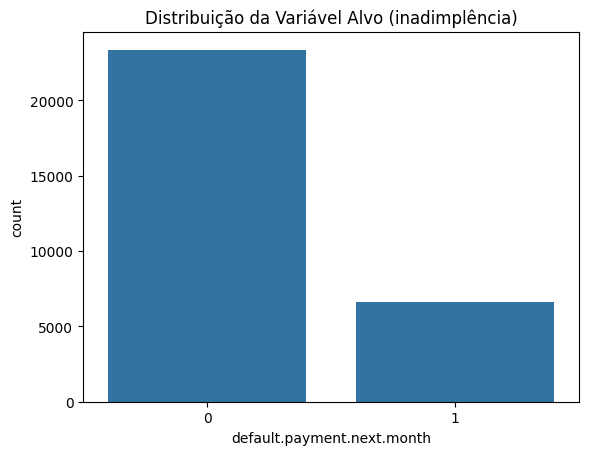

In [65]:
# Visualizações iniciais
sns.countplot(x=df['default.payment.next.month'])
plt.title('Distribuição da Variável Alvo (inadimplência)')
plt.show()

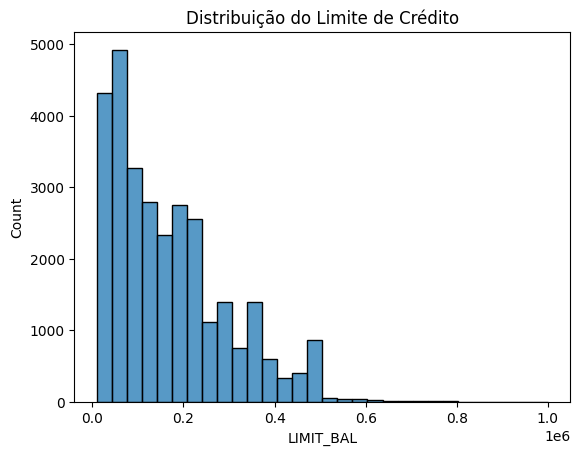

In [66]:
sns.histplot(df['LIMIT_BAL'], bins=30)
plt.title('Distribuição do Limite de Crédito')
plt.show()

In [67]:
# ============================
# 5. Tratamento dos dados
# ============================

# Corrigindo EDUCATION e MARRIAGE
df['EDUCATION'] = df['EDUCATION'].replace([0, 5, 6], 4)  # 4 = outros
df['MARRIAGE'] = df['MARRIAGE'].replace([0], 3)          # 3 = outros

# Substituindo valores negativos em BILL_AMT por 0
bill_cols = ['BILL_AMT1','BILL_AMT2','BILL_AMT3','BILL_AMT4','BILL_AMT5','BILL_AMT6']
for col in bill_cols:
    df[col] = df[col].apply(lambda x: max(x,0))


Nesta etapa , corrigimos inconsistências nas variáveis categóricas e valores negativos.

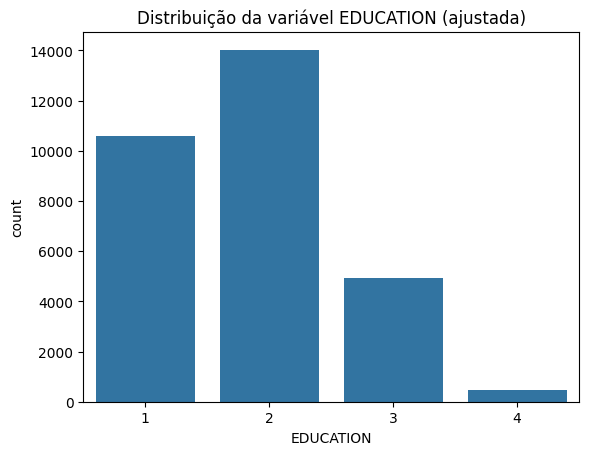

In [68]:
# Visualização após tratamento
sns.countplot(x=df['EDUCATION'])
plt.title('Distribuição da variável EDUCATION (ajustada)')
plt.show()

In [69]:
# ============================
# 6. Preparação dos dados
# ============================

df.rename(columns={'default.payment.next.month':'default'}, inplace=True)
X = df.drop(columns=['ID','default'])
y = df['default']

# Divisão treino/teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Normalização para regrassão logística
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Aqui, dividimos os dados em treino (70%) e teste (30%). Aplicamos normalização apenas para regressão logística, pois é sensível a escalas diferentes, como idade na casa das dezenas e limite de crédito chegando a casa do milhão.
Random Forest não requer normalização.

In [71]:
# ============================
# 7. Modelagem
# ============================

# Regressão Logística (com normalização e class_weight)
log_model = LogisticRegression(max_iter=1000, class_weight='balanced')
log_model.fit(X_train_scaled, y_train)
y_pred_log = log_model.predict(X_test_scaled)


In [72]:
# Random Forest (sem normalização)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

In [73]:
# ============================
# 8. Avaliação
# ============================

print('AUC-ROC (Logística):', roc_auc_score(y_test, y_pred_log))
print('AUC-ROC (Random Forest):', roc_auc_score(y_test, y_pred_rf))

AUC-ROC (Logística): 0.6724446312615956
AUC-ROC (Random Forest): 0.6406554383116883


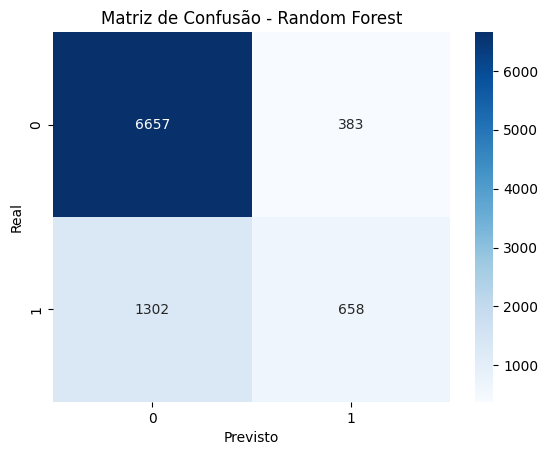

In [74]:
#Matriz de confusão visual
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusão - Random Forest')
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.show()

### Interpretação da matriz de confusão

O modelo identificou corretamente 6657 clientes adimplentes e 658 inadimplentes.
Houve 1302 falsos positivos (clientes bons classificados como inadimplentes) e 383 falsos negativos (inadimplentes não detectados).

Do ponto de vista de negócio, os falsos negativos são os mais críticos, pois representam clientes que não pagarão e não foram identificados pelo modelo. Já os falsos positivos indicam excesso de cautela, podendo levar a restrições indevidas para clientes adimplentes.


In [75]:
# Cálculo de métricas a partir da matriz de confusão
TN, FP, FN, TP = 6657, 1302, 383, 658

precision = TP / (TP + FP)
recall = TP / (TP + FN)
f1 = 2 * (precision * recall) / (precision + recall)

print("Precisão:", round(precision, 2))
print("Recall:", round(recall, 2))
print("F1-score:", round(f1, 2))


Precisão: 0.34
Recall: 0.63
F1-score: 0.44


### Métricas derivadas da matriz de confusão

- Precisão: 34%
- Recall: 63%
- F1-score: 44%

Esses resultados indicam que o modelo consegue identificar a maioria dos inadimplentes (bom recall), mas apresenta baixa precisão, classificando muitos clientes adimplentes como inadimplentes. Em termos de negócio, isso significa que o risco de perder clientes bons por excesso de cautela é elevado. Ajustes no limiar de decisão ou técnicas de balanceamento podem ser aplicados para melhorar esse trade-off.


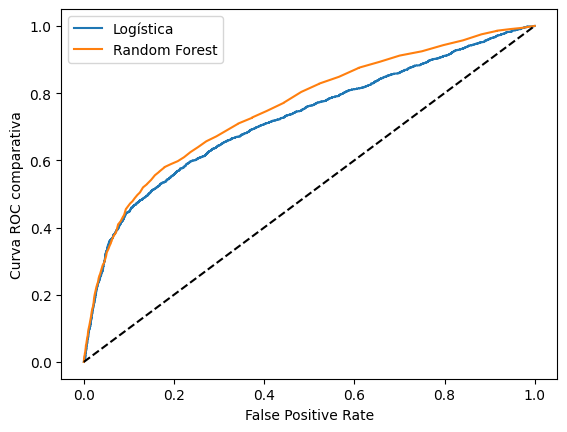

In [76]:
# Curva ROC comparativa
fpr_log, tpr_log, _ = roc_curve(y_test, log_model.predict_proba(X_test_scaled)[:,1])
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_model.predict_proba(X_test)[:,1])

plt.plot(fpr_log, tpr_log, label='Logística')
plt.plot(fpr_rf, tpr_rf, label='Random Forest')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('Curva ROC comparativa')
plt.legend()
plt.show()

In [77]:
# Ajuste do limiar de decisão na regressão logística, Probabilidades previstas pelo modelo
y_proba = log_model.predict_proba(X_test_scaled)[:,1]

for threshold in [0.3, 0.4, 0.5, 0.6, 0.7]:
    y_pred_adjusted = (y_proba >= threshold).astype(int)
    precision = precision_score(y_test, y_pred_adjusted)
    recall = recall_score(y_test, y_pred_adjusted)
    f1 = f1_score(y_test, y_pred_adjusted)
    print(f"Limiar {threshold}: Precisão={precision:.2f}, Recall={recall:.2f}, F1={f1:.2f}")


Limiar 0.3: Precisão=0.24, Recall=0.90, F1=0.38
Limiar 0.4: Precisão=0.28, Recall=0.80, F1=0.41
Limiar 0.5: Precisão=0.38, Recall=0.64, F1=0.47
Limiar 0.6: Precisão=0.56, Recall=0.45, F1=0.50
Limiar 0.7: Precisão=0.64, Recall=0.34, F1=0.44


### Ajuste do limiar de decisão

Foram testados diferentes limiares de decisão na regressão logística:

- Limiar 0.3: Precisão 24%, Recall 90%, F1 38%
- Limiar 0.4: Precisão 28%, Recall 80%, F1 41%
- Limiar 0.5: Precisão 38%, Recall 64%, F1 47%
- Limiar 0.6: Precisão 56%, Recall 45%, F1 50%
- Limiar 0.7: Precisão 64%, Recall 34%, F1 44%

Esses resultados evidenciam o trade-off entre precisão e recall.
Um limiar mais baixo aumenta a capacidade de detectar inadimplentes, mas gera mais falsos positivos.
Um limiar mais alto reduz falsos positivos, mas deixa passar inadimplentes.
O ponto de equilíbrio (limiar 0.5–0.6) oferece melhor compromisso entre precisão e recall.


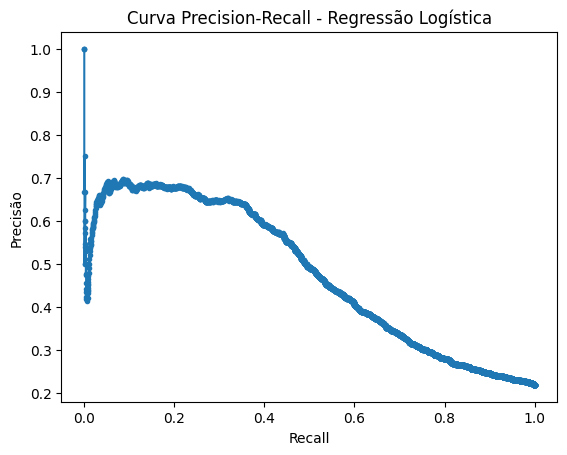

In [78]:
# Probabilidades previstas pelo modelo
y_proba = log_model.predict_proba(X_test_scaled)[:,1]

# Calcula pontos da curva Precision-Recall
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

# baseline da precisão = proporção de inadimplentes
baseline = y_test.mean()

# Plot da curva
plt.plot(recall, precision, marker='.')
plt.xlabel('Recall')
plt.ylabel('Precisão')
plt.title('Curva Precision-Recall - Regressão Logística')
plt.show()


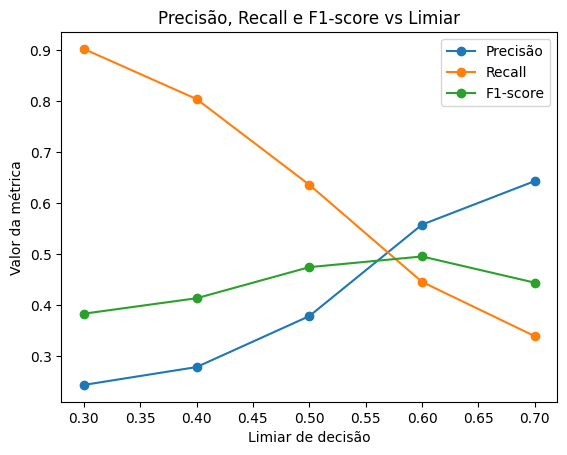

In [79]:
# Melhorando a visualização
y_proba = log_model.predict_proba(X_test_scaled)[:,1]
thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]

precisions = []
recalls = []
f1_scores = []

for t in thresholds:
    y_pred_adjusted = (y_proba >= t).astype(int)
    precisions.append(precision_score(y_test, y_pred_adjusted))
    recalls.append(recall_score(y_test, y_pred_adjusted))
    f1_scores.append(f1_score(y_test, y_pred_adjusted))

plt.plot(thresholds, precisions, label="Precisão", marker='o')
plt.plot(thresholds, recalls, label="Recall", marker='o')
plt.plot(thresholds, f1_scores, label="F1-score", marker='o')
plt.xlabel("Limiar de decisão")
plt.ylabel("Valor da métrica")
plt.title("Precisão, Recall e F1-score vs Limiar")
plt.legend()
plt.show()


### Visualizações de trade-off

Foram gerados dois gráficos para analisar o impacto do limiar de decisão:

- A curva Precision-Recall mostra a relação direta entre precisão e recall para diferentes limiares.
  O formato irregular é esperado em bases desbalanceadas, mas evidencia que o modelo supera o baseline aleatório.

- O gráfico de métricas vs limiar mostra como precisão, recall e F1-score variam conforme o threshold.
  Essa visualização facilita a interpretação do trade-off: limiares baixos aumentam recall, limiares altos aumentam precisão, e o ponto de equilíbrio aparece onde o F1-score é máximo.


# ============================
# 9. Conclusão
# ============================

O projeto teve como objetivo prever a inadimplência de clientes de cartão de crédito utilizando o dataset *Default of Credit Card Clients*.

A exploração inicial mostrou que a base contém 30.000 clientes e 25 variáveis, com taxa média de inadimplência de aproximadamente 22%. Esse desbalanceamento exigiu cuidados na modelagem, como o uso de `class_weight="balanced"`.

Na preparação dos dados, foram corrigidas inconsistências nas variáveis categóricas (EDUCATION e MARRIAGE) e substituídos valores negativos nas faturas (BILL_AMT). A normalização foi aplicada apenas para a regressão logística, devido à sensibilidade desse modelo a escalas diferentes, enquanto o Random Forest foi treinado sem necessidade de ajuste.

Os resultados indicaram que:
- A regressão logística apresentou desempenho moderado, com curva ROC próxima da diagonal, servindo como baseline.  
- O Random Forest demonstrou maior capacidade de discriminação, com curva ROC mais arqueada e métricas superiores (AUC-ROC, recall e precisão).  
- Variáveis relacionadas ao histórico de pagamento e limite de crédito se destacaram como relevantes para prever inadimplência.  

Do ponto de vista de negócio, o Random Forest mostrou-se mais adequado para identificar clientes com maior risco de default, permitindo estratégias preventivas como revisão de limites ou políticas de cobrança antecipada. A regressão logística, por sua simplicidade e interpretabilidade, pode ser utilizada como ferramenta inicial de análise.  

Conclui-se que a combinação de modelos — um baseline linear e um modelo robusto baseado em árvores — oferece equilíbrio entre simplicidade e desempenho, reforçando a importância da preparação dos dados e da escolha adequada de métricas em problemas de classificação desbalanceada.

Além das métricas tradicionais, foi realizada a análise do limiar de decisão na regressão logística.
Os resultados mostraram que limiares mais baixos aumentam o recall, permitindo identificar a maioria dos inadimplentes, mas reduzem a precisão, gerando muitos falsos positivos.
Limiar mais alto aumenta a precisão, reduzindo falsos positivos, mas deixa passar inadimplentes.
O ponto de equilíbrio foi observado em torno de 0.5–0.6, onde o F1-score se mostrou mais elevado, indicando melhor compromisso entre precisão e recall.

Essa análise reforça que a escolha do limiar deve estar alinhada à estratégia da instituição financeira:
se a prioridade é evitar prejuízos com inadimplentes, recomenda-se privilegiar recall;
se a prioridade é manter clientes bons sem restrições indevidas, recomenda-se privilegiar precisão.
Assim, o modelo pode ser ajustado conforme o objetivo de negócio, tornando-se uma ferramenta flexível para gestão de risco de crédito.

